## Практическое занятие 2
### Прогнозирование временных рядов (регресионные машиного обучения)

Прогнозирование временных рядов означает продолжение данных прошлых периодов в будущее, где эти значения еще не доступны. Прогнозирование обычно выполняется для оптимизации таких областей как уровень товарных запасов, производственных мощностей и количества персонала.

Вопределении временных рядов есть две основные структурные переменные:

Период, который представляет уровень обобщения. Наиболее часто используемыми периодами являются: месяц, неделя, день в цепях поставок (для оптимизации товарных запасов). Колл-центры обычно ориентируются на период в 15 минут (для оптимизации количества персонала).

Горизонт, который представляет количество периодов в будущем, на которое необходим прогноз. В цепях поставок горизонт обычно равен или превышает срок поставки. Данная лабораторная работа посвящена прогнозрованию энергопотребления по данным, собранным за 12 лет. Тренировочная выборка состоит из 11 лет, тестовая из одного года.

### Загрузка, инициализация и анализ данных

In [ ]:
#Команда импорта сторонних библиотек (import 'название библиотеки' as 'сокращенное название')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Ссылка на датасет
url='https://raw.githubusercontent.com/jenfly/opsd/refs/heads/master/opsd_germany_daily.csv'

# Операция присваивания переменной data датафрейма (дф), который формируется на основе датасета
data = pd.read_csv(url, sep=",")
data_copied = data.copy()
data # Вывод полученного дф (рабоатет только в интерактивных блокнотаз

,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.18400,NaN,NaN,NaN
1,2006-01-02,1380.52100,NaN,NaN,NaN
2,2006-01-03,1442.53300,NaN,NaN,NaN
3,2006-01-04,1457.21700,NaN,NaN,NaN
4,2006-01-05,1477.13100,NaN,NaN,NaN
...,...,...,...,...,...
4378,2017-12-27,1263.94091,394.507,16.530,411.037
4379,2017-12-28,1299.86398,506.424,14.162,520.586
4380,2017-12-29,1295.08753,584.277,29.854,614.131
4381,2017-12-30,1215.44897,721.247,7.467,728.714


#### Базовые библиотеки, которые могут использоваться при машинном обучении и анализе данных:

    1.Pandas - Хранение, обработка и анализ датасетов (табличный формат, временые ряды)
    
    2.Numpy - Хранение, обработка и анализ датасетов (многомерные массивы)
    
    3.Sklearn - Библиотека машинного обуения
    
    4.SciPy - Библиотека научных и инженерных рассчетов
    
    5.Seaborn - Библиотека визуализации (построение графиков), основана на библ. matplotlib
    
    6.Matplotlib - Библиотека визуализации

Графическая демонтрация всего обрабатываемого датасета атрибуты функции x_vars - значения оси абсцисс, data - датасет, height - высота графика (inch),aspect - длина графика

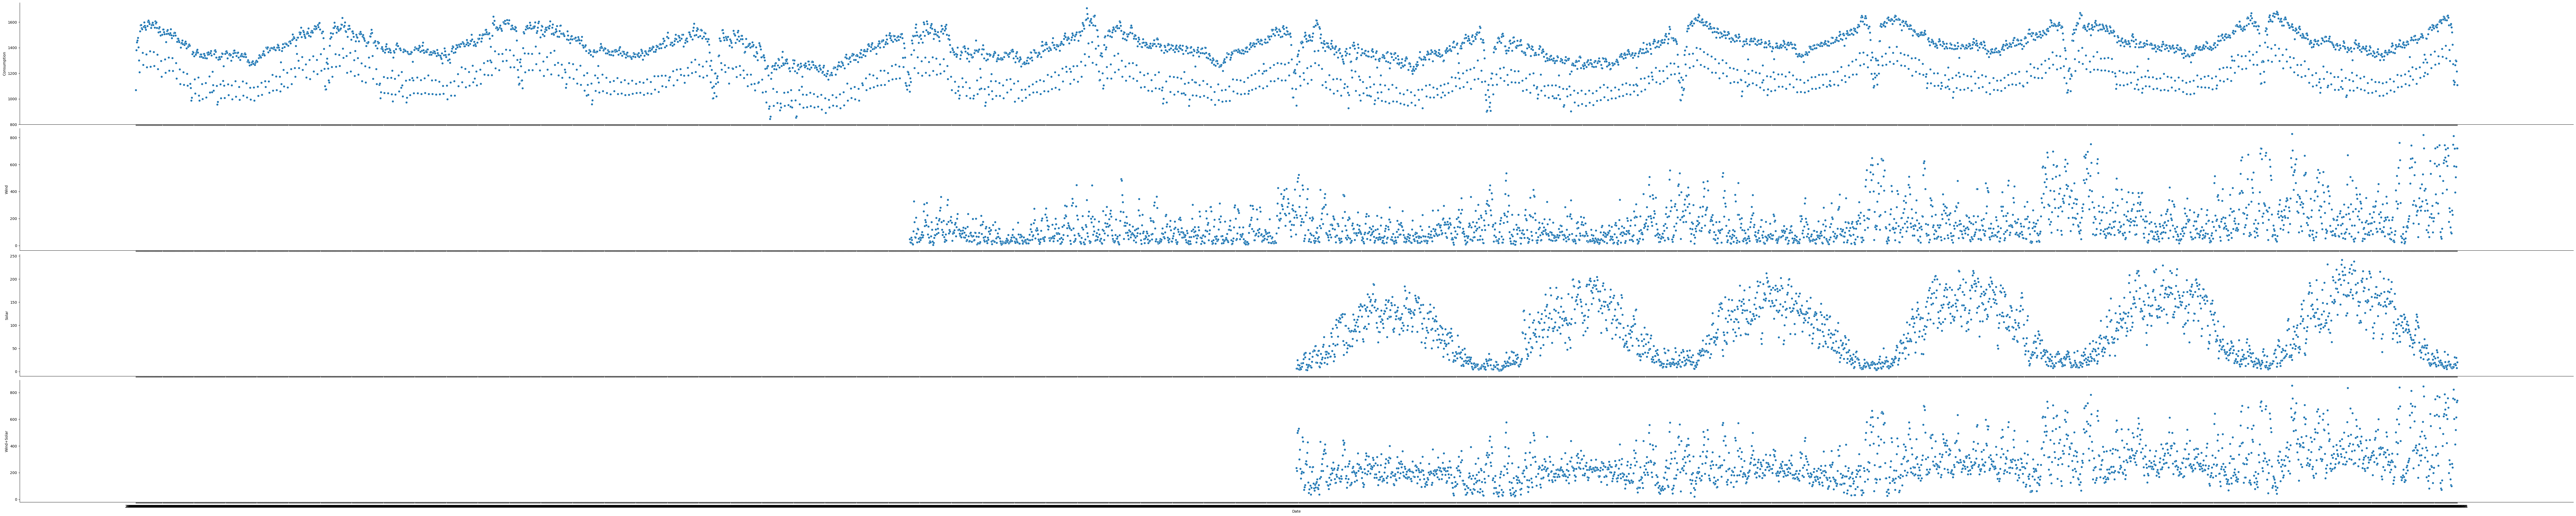

In [ ]:
sns.pairplot(x_vars=['Date'], data = data, height=5, aspect=20)

Проверка коллинеарности между атрибутами набора данных — один из основных этапов предварительной обработки данных.Хороший способ понять корреляцию между компонентами — создать точечные диаграммы для каждой пары признаков.
Каждая диаграмма рассеяния в матрице помогает нам понять корреляцию между соответствующей парой атрибутов. Как мы видим, median_income и median_house_value довольно сильно коррелируют. Главная диагональ содержит гистограммы для каждого атрибута.

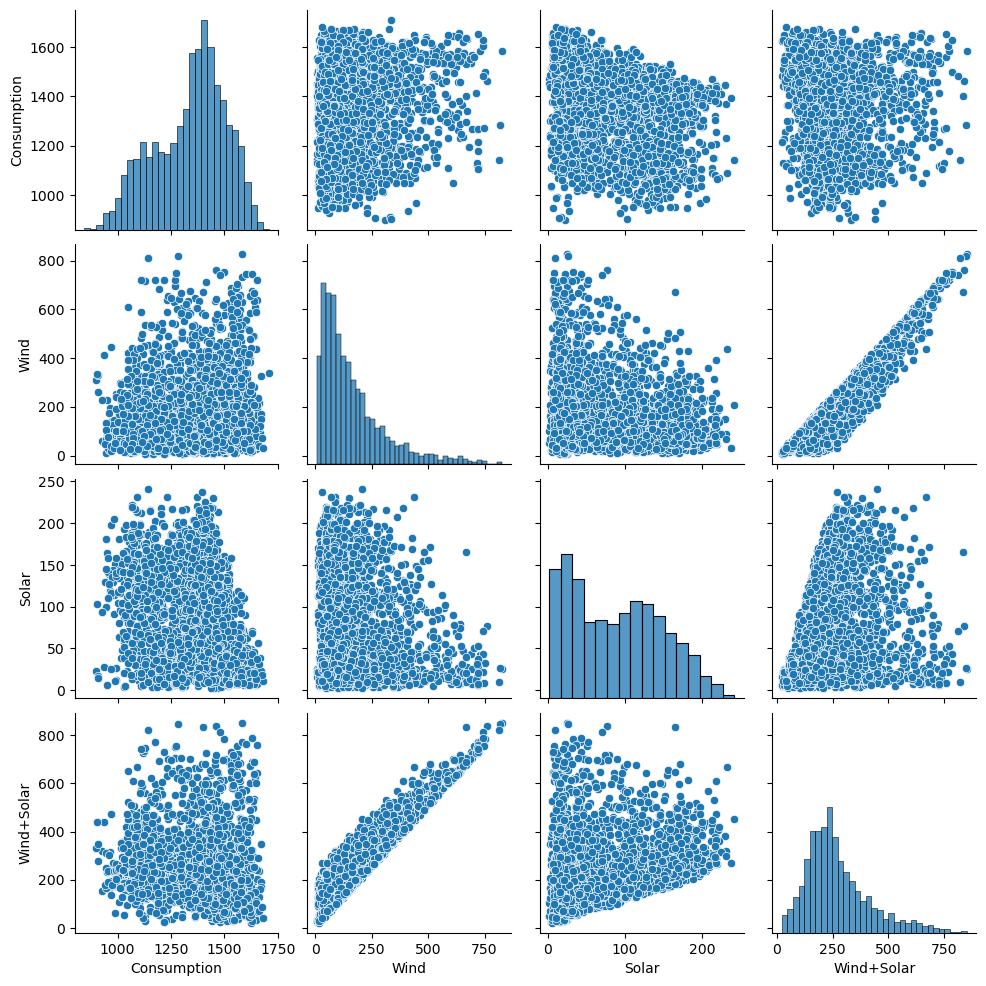

In [ ]:
sns.pairplot(data = data) # Матрица рассеяния (перекрестный анализ)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         4383 non-null   object 
 1   Consumption  4383 non-null   float64
 2   Wind         2920 non-null   float64
 3   Solar        2188 non-null   float64
 4   Wind+Solar   2187 non-null   float64
dtypes: float64(4), object(1)
memory usage: 171.3+ KB


### Подготовка временных меток

In [ ]:
data['time'] = str('01:00:00') # Добавление временной составляющей
data['Date'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['time'].astype(str), format='%Y-%m-%d %H:%M:%S') # Формирование формата времени с датой

data

,Date,Consumption,Wind,Solar,Wind+Solar,time
0,2006-01-01 01:00:00,1069.18400,NaN,NaN,NaN,01:00:00
1,2006-01-02 01:00:00,1380.52100,NaN,NaN,NaN,01:00:00
2,2006-01-03 01:00:00,1442.53300,NaN,NaN,NaN,01:00:00
3,2006-01-04 01:00:00,1457.21700,NaN,NaN,NaN,01:00:00
4,2006-01-05 01:00:00,1477.13100,NaN,NaN,NaN,01:00:00
...,...,...,...,...,...,...
4378,2017-12-27 01:00:00,1263.94091,394.507,16.530,411.037,01:00:00
4379,2017-12-28 01:00:00,1299.86398,506.424,14.162,520.586,01:00:00
4380,2017-12-29 01:00:00,1295.08753,584.277,29.854,614.131,01:00:00
4381,2017-12-30 01:00:00,1215.44897,721.247,7.467,728.714,01:00:00


### Построение графика зависимости даты только от энергопотребления (библ. seaborn (sns))

<Axes: xlabel='Date', ylabel='Consumption'>

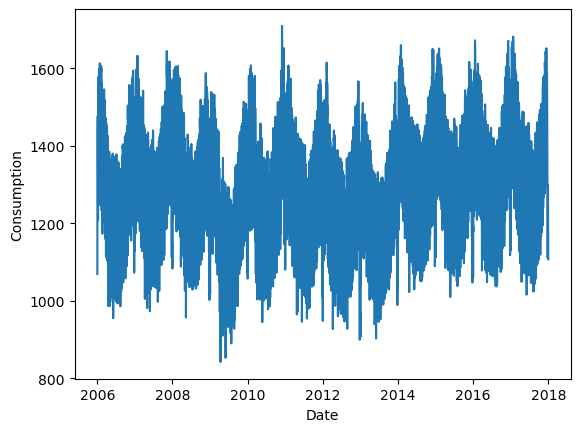

In [ ]:
sns.lineplot(data=data, x=data['Date'], y=data['Consumption'])

### Построение автокорреляционной функции (АКФ)

Автокорреляция

Автокорреляция также показывает степень взаимосвязи в диапазоне от –1 до 1, но только не двух переменных, а одной и той же переменной в разные моменты времени.

Автокорреляция позволяет выявлять тренд и сезонность, а также используется при подборе параметров моделей. В частности, мы видим, что лаг 12 сильнее коррелирует с исходным рядом, чем соседние лаги 10 и 11. То же самое можно сказать и про лаг 24. Такая автокорреляция позволяет предположить наличие (ежегодных) сезонных колебаний.

Постоянно положительная корреляция говорит о наличии тренда.

ACF: показывает корреляцию временного ряда с его лагами.

In [ ]:
# import warnings
# warnings.filterwarnings("ignore")

In [ ]:
dates = []
for i in range(len(data_copied['Date'])):
    dates.append(data_copied['Date'][i])

In [ ]:
data_copy = data_copied.T
dataToAdd = data_copy.tail(-1)
data_N = pd.DataFrame(dataToAdd.values, columns=dates)
data_N

,2006-01-01,2006-01-02,2006-01-03,2006-01-04,2006-01-05,2006-01-06,2006-01-07,2006-01-08,2006-01-09,2006-01-10,...,2017-12-22,2017-12-23,2017-12-24,2017-12-25,2017-12-26,2017-12-27,2017-12-28,2017-12-29,2017-12-30,2017-12-31
0,1069.184,1380.521,1442.533,1457.217,1477.131,1403.427,1300.287,1207.985,1529.323,1576.911,...,1423.23782,1272.17085,1141.7573,1111.28338,1130.11683,1263.94091,1299.86398,1295.08753,1215.44897,1107.11488
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,228.773,748.074,812.422,587.81,717.453,394.507,506.424,584.277,721.247,721.176
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.065,8.45,9.949,15.765,30.923,16.53,14.162,29.854,7.467,19.98
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,238.838,756.524,822.371,603.575,748.376,411.037,520.586,614.131,728.714,741.156


In [ ]:
data_N.loc[0,'2012-01-01': '2013-01-31']

2012-01-01     948.128
2012-01-02    1269.581
2012-01-03    1334.745
2012-01-04    1347.136
2012-01-05    1376.658
                ...   
2013-01-27    1140.584
2013-01-28     1410.84
2013-01-29    1411.595
2013-01-30    1377.521
2013-01-31     1356.59
Name: 0, Length: 397, dtype: object

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

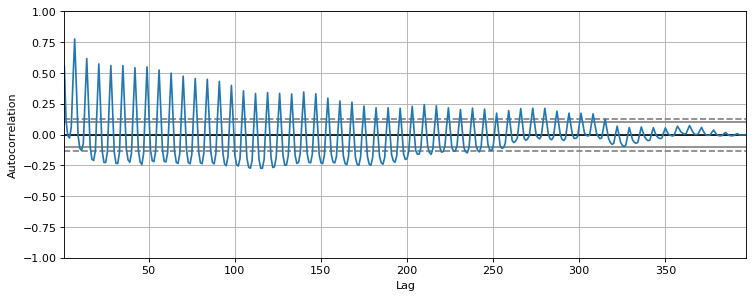

In [ ]:
plt.figure(figsize=(11,4), dpi= 80) # Инициализация подложки графика
#Построение АКФ средствами библиоткеи pandas (функции plotting и autocorrelation_plot)
#Функция .loc позволяет обратиться к группе строчек или колонок по
#соответствующим названиям индексов или названиям колонок.
#В примере ниже выбирается набор строк колонки 'Consumption' дф data в диапазоне даты
#от '2012-01-01' до '2013-01-31' и передается функции вычисления и построения АКФ.
pd.plotting.autocorrelation_plot(data_N.loc[0,'2012-01-01': '2013-01-31'])

### Блок построения временных трендов с усреднением по 7 и 365 дней по колонке 'Consumption'

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\294764235.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_365d_rol['Consumption'] = data_365d_rol['Consumption'].fillna(method = 'bfill').fillna(method = 'ffill')


0.5

1.0

'Trends in Electricity Consumption'

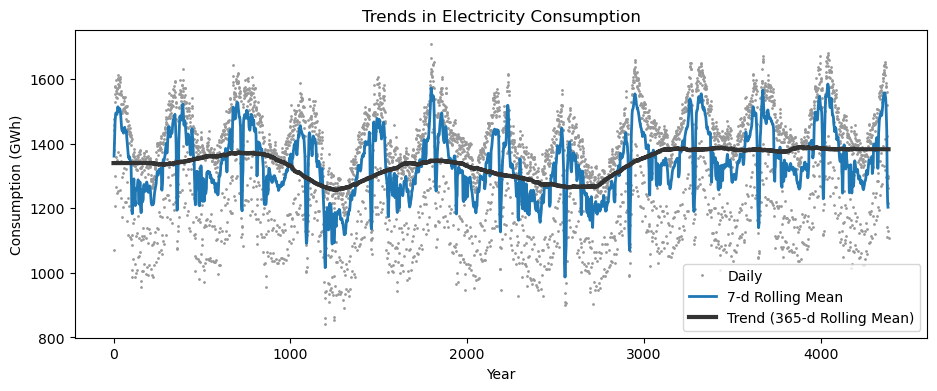

In [ ]:
data_columns = ['Consumption', 'Wind', 'Solar', 'Wind+Solar']

# data_365d_rol - название дф, в который заносятся колонки с усреднением за 365 дней (функции rolling() и mean())
data_365d_rol = data[data_columns].rolling(window = 365, center = True).mean()
# data_7d_rol - название дф, в который заносятся колонки с усреднением за 7 дней (функции rolling() и mean())
data_7d_rol = data[data_columns].rolling(window = 7, center = True).mean()

data_365d_rol['Consumption'] = data_365d_rol['Consumption'].fillna(method = 'bfill').fillna(method = 'ffill')

# Построение графика с помощью библиотеки matplitlib (plt)
fig, ax = plt.subplots(figsize = (11,4)) # Инициализация графика fig - подложка (холст), ax - оси

#Построение колонки 'Consumption' дф data, через запятую передаются атрибуты для настройки графика
#marker - маркер точки на графике, markersize - размер маркера, color - цвет,
#linestyle - тип линии (если используется),
#label - подпись графика (не заголовок, отображается функцией legend())
ax.plot(data['Consumption'], marker='.', markersize=2, color='0.6', linestyle='None', label='Daily')

# Построение колонки 'Consumption' дф data_7d_rol
ax.plot(data_7d_rol['Consumption'], linewidth=2, label='7-d Rolling Mean')

# Построение колонки 'Consumption' дф data_365d_rol
ax.plot(data_365d_rol['Consumption'], color='0.2', linewidth=3, label='Trend (365-d Rolling Mean)')

#Добваление на график таблички (права низ) с названиями графиков
ax.legend()

#Добавление названия оси абсцисс
ax.set_xlabel('Year')

#Добавление названия оси ординат
ax.set_ylabel('Consumption (GWh)')

#Добавление названия всего графика
ax.set_title('Trends in Electricity Consumption')

display(0.5, 1.0, 'Trends in Electricity Consumption')

### Формирование функции вычисления точности прогнозной модели

Метрики точности модели — это количественные показатели, которые используются для оценки качества работы регрессионных моделей. Вот краткое описание каждой из них:

### 1. R² (Коэффициент детерминации)
$R²$ измеряет долю вариации зависимой переменной, объясняемую независимыми переменными в модели. Значение $R²$ варьируется от 0 до 1:
- **0** означает, что модель не объясняет никакой вариации в данных.
- **1** означает, что модель полностью объясняет вариацию в данных.
Чем выше значение $R²$, тем лучше модель объясняет данные.

### 2. RMSE (Корень среднеквадратичной ошибки)
RMSE — это мера того, насколько близки предсказанные значения к фактическим значениям. Он вычисляется как корень квадратный из средней квадратичной ошибки:
$$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$
где $y_i$ — фактические значения, $\hat{y}_i$ — предсказанные значения, а $n$ — количество наблюдений. Низкое значение RMSE указывает на высокую точность модели.

### 3. MAE (Средняя абсолютная ошибка)
MAE измеряет среднюю абсолютную разницу между фактическими и предсказанными значениями:
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
MAE дает представление о том, насколько сильно предсказания модели отличаются от фактических значений. Чем меньше значение MAE, тем точнее модель.

### 4. MSE (Средняя квадратичная ошибка)
MSE — это среднее значение квадратов ошибок между фактическими и предсказанными значениями:
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
MSE также показывает, насколько близки предсказанные значения к фактическим. Однако, в отличие от MAE, MSE более чувствителен к большим ошибкам, так как ошибки возводятся в квадрат. Чем меньше значение MSE, тем лучше модель.

### Заключение
Эти метрики помогают оценить производительность модели и выбрать наиболее подходящий алгоритм для конкретной задачи. Разные метрики могут дать разные представления о качестве модели, поэтому важно рассматривать их в совокупности.

In [ ]:
import sklearn.metrics as metrics # Импорт библиотеки по рассчету метрик ошибки

import numpy as np

#def - инициализация функции, далее идет название и передаваемые атрибуты
#y_true - исходный дф, y_pred - спрогнозированный дф, model - название модели машинного обучения

def regression_results(y_true, y_pred, model):

    #Метрики регресионных моделей

    #Средняя абсолютная ошибка
    mean_absolute_error = metrics.mean_absolute_error(y_true, y_pred)

    # Средняя квадратичная ошибка
    mse = metrics.mean_squared_error(y_true, y_pred)

    # Медианная вбсолютная ошибка
    median_absolute_error = metrics.median_absolute_error(y_true, y_pred)

    #Коэффициент детерминации (R^2) - определяет степень соответствия
    #полученной в ходе МО модели исходным данным. (Модели с коэфф. детерм.
    #более 0,8 (80%) считаются достаточно точными)
    r2 = metrics.r2_score(y_true, y_pred)

    # Вывод вычисленных метрик
    print(' ')
    print(model)

    #print('explained_variance: ', round(explained_variance,4))

    #print('mean_squared_log_error: ', round(mean_squared_log_error,4))

    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))

### Реализации алгоритмов машинного обучения

Вданном блоке представлены регресионные алгоритмы машинного обучения:

    1.LinearRegression - линейная ргерессия;
    2.RandomForestRegressor - регрессия случайного леса;
    3.KNeighborsRegressor - регрессия по типу к - соседних;
    4.SVR (Support Vector Machine) - машина опорных векторов;
    5.MLPRegressor (Multi-layer Perceptron regressor) - многослойная нейронная сеть по типу перцептрона.

### 1. LinearRegression (Линейная регрессия)
Линейная регрессия — это простой и широко используемый метод для моделирования зависимости между одной зависимой переменной и одной или несколькими независимыми переменными. Она предполагает, что существует линейная связь между переменными, и пытается найти наилучшие параметры (коэффициенты) для уравнения прямой линии, минимизируя сумму квадратов ошибок (разницы между предсказанными и фактическими значениями).

### 2. RandomForestRegressor (Регрессия случайного леса)
Random Forest — это ансамблевый метод, который использует множество деревьев решений для улучшения точности предсказаний. Каждый "лес" состоит из множества деревьев, которые обучаются на случайных подмножествах данных и признаков. Предсказания делаются путем усреднения результатов всех деревьев. Это помогает уменьшить переобучение и повысить стабильность модели.

### 3. KNeighborsRegressor (Регрессия по типу k-соседних)
Метод k ближайших соседей (k-NN) — это простой алгоритм, который предсказывает значение целевой переменной на основе значений ближайших k соседей в пространстве признаков. Алгоритм вычисляет расстояния между точками и выбирает k ближайших соседей, а затем усредняет их значения для получения предсказания. Этот метод хорошо работает с небольшими наборами данных, но может быть медленным при больших объемах.

### 4. SVR (Support Vector Regression, Машина опорных векторов для регрессии)
SVR — это расширение метода опорных векторов (SVM) для задач регрессии. Он пытается найти гиперплоскость, которая максимально точно предсказывает целевую переменную, при этом оставляя как можно меньше ошибок в пределах заданного "эпсилон-интервала". SVR хорошо справляется с высокоразмерными данными и может использовать различные ядра для моделирования сложных зависимостей.

### 5. MLPRegressor (Многослойная нейронная сеть по типу перцептрона)
MLPRegressor — это модель многослойной перцептронной нейронной сети, которая состоит из входного слоя, одного или нескольких скрытых слоев и выходного слоя. Она использует нелинейные активационные функции для моделирования сложных зависимостей между входными и выходными данными. Модель обучается с помощью алгоритма обратного распространения ошибки. MLPRegressor хорошо подходит для задач регрессии, особенно когда данные имеют сложные и нелинейные зависимости.

Эти алгоритмы имеют свои преимущества и недостатки, и выбор подходящего метода зависит от конкретной задачи и характеристик данных.

### Цель

Целью является произвести прогнозирование временного ряда 'Consumption' (энергопотребление). Для этого необходимо произвести тренировку модели МО по данным дф data['Consumption'], т.е. использовать в качестве изменяемой величины значение энергопотребления, а неизменяемой - время. Чтобы провести дальнейшую оценку точности обученной модели исходный датасет в начале делится на две части - тренировочную (X_train и y_train) и тестовую (X_test и y_test), где к переменной X относится неизменяемая составляющая (пр. время и ее составляющие), а к y - изменяемая, т.е. в текущем случае значения энергопотребления (дф data['Consumption']). Проверка обученной модели выполняется при помощи функции regression_results(), которая возвращает набор различных метрик оценки точности обученной модели. Строятся графики сравнения реального временного хода значений энергопотребления y_test и спрогнозированног (y_pred) на идентичный период времени.

In [ ]:
#Импорт библиотеки деления датасета на выборки (TimeSeriesSplit) и перекрестного анализа (cross_val_score)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

#Импорт библиотек МО
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [ ]:
# Копирование исхолного дф
data_consumption = data[['Consumption', 'Date']]

# Добавление новой колонки со вчерашними значениями (сдвиг колонки 'Consumption' на шаг назад)
data_consumption.loc[:,'Yesterday'] = data_consumption.loc[:,'Consumption'].shift()

#Добавление колонки с разностью между значениями одно и двух дневной давности
data_consumption.loc[:,'Yesterday_Diff'] = data_consumption.loc[:,'Yesterday'].diff()

#Удаление из дф значений NaN
data_consumption = data_consumption.dropna().reset_index(drop=True)

In [ ]:
print(len(data_consumption), len(data), sep='\n')

4381
4383


In [ ]:
4381-365

4016

In [ ]:
data_consumption[:4016]
# data_consumption.loc[:4016, 'Consumption']

# data_consumption[4017:]
# data_consumption.loc[4017:, 'Consumption']

,Consumption,Date,Yesterday,Yesterday_Diff
0,1442.533,2006-01-03 01:00:00,1380.521,311.337
1,1457.217,2006-01-04 01:00:00,1442.533,62.012
2,1477.131,2006-01-05 01:00:00,1457.217,14.684
3,1403.427,2006-01-06 01:00:00,1477.131,19.914
4,1300.287,2006-01-07 01:00:00,1403.427,-73.704
...,...,...,...,...
4011,1289.324,2016-12-27 01:00:00,1121.213,3.540
4012,1294.881,2016-12-28 01:00:00,1289.324,168.111
4013,1295.897,2016-12-29 01:00:00,1294.881,5.557
4014,1291.044,2016-12-30 01:00:00,1295.897,1.016


In [ ]:
# Формаирование тренировочнйо части датасета
X_train = data_consumption[:4016].drop(['Consumption', 'Date'], axis = 1)
y_train = data_consumption.loc[:4015, 'Consumption']

# # Формирование тестовой части датасета
X_test = data_consumption[4016:].drop(['Consumption', 'Date'], axis = 1)
y_test = data_consumption.loc[4016:, 'Consumption']

DataForPlot = data_consumption['Date'][4016:]

# data_N.loc[0,'2012-01-01': '2013-01-01']

In [ ]:
exp = [X_train, y_train, X_test, y_test, dataForPlot]
for el in exp:
    print(el.shape)

(4016, 2)
(4016,)
(365, 2)
(365,)
(365,)


In [ ]:
#Объявление алгоритмов МО и аккумуляция их в массив

#для удобной работы в цикле
models = [] # Лист для хранения моделей
models.append(('LR', LinearRegression()))

models.append(('NN', MLPRegressor(solver = 'lbfgs')))
# solver - определение ядра принятия решений
# Алгоритм “lbfgs” используется по умолчанию из-за его надежности.
# Эта модель оптимизирует среднеквадратичную ошибку с помощью LBFGS

models.append(('KNN', KNeighborsRegressor()))
models.append(('RF', RandomForestRegressor(n_estimators = 50))) # n_estimators - число деревьев в ансамбле
models.append(('SVR', SVR(gamma='auto', kernel='rbf'))) # kernel - ядро по которому формируется опорный вектор

In [ ]:
# Рассчетный цикл
results = [] # Лист для хранения результата оценки модели
names = [] # Лист для хранения имени модели

# Начало цикла for
for name, model in models:

    #TimeSeriesSplit определяет количество частей на которые будет разбит датасет,
    #переменная tscv используется как атрибут функции cross_val_score(), т.е.
    #определяет количество частей датасета по которым будет проведен перекрестный
    #анализ (валидация результатов по метрике R^2)
    tscv = TimeSeriesSplit(n_splits=10)
    cv_results = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')

    # Добавление результатов в лист results и names
    results.append(cv_results)
    names.append(name)

    # Вывод результатов
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.343747 (0.029773)
NN: 0.410567 (0.197565)
KNN: 0.646307 (0.083185)
RF: 0.632209 (0.081760)
SVR: -0.117944 (0.157755)


# Ящик с усами (box plot)
— график, использующийся в описательной статистике, отображает медиану, нижний и верхний квартили, минимальное и максимальное значение выборки и выбросы, а еще — плотность и симметричность распределения. Несколько таких ящиков можно нарисовать бок о бок, чтобы визуально сравнивать одно распределение с другим.

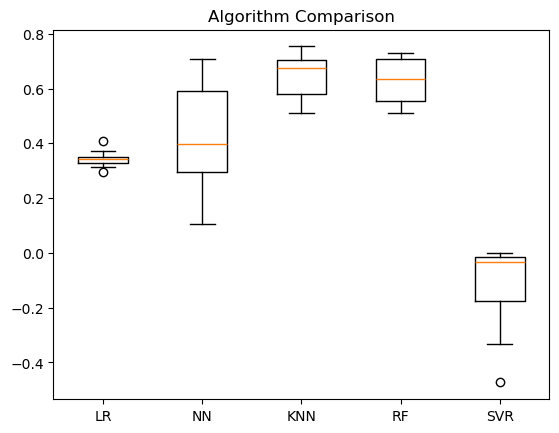

In [ ]:
#График сравнения используемых алгоритмов
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()

 
LinearRegression()
r2:  0.3802
MAE:  104.2855
MSE:  16785.2379
RMSE:  129.5579


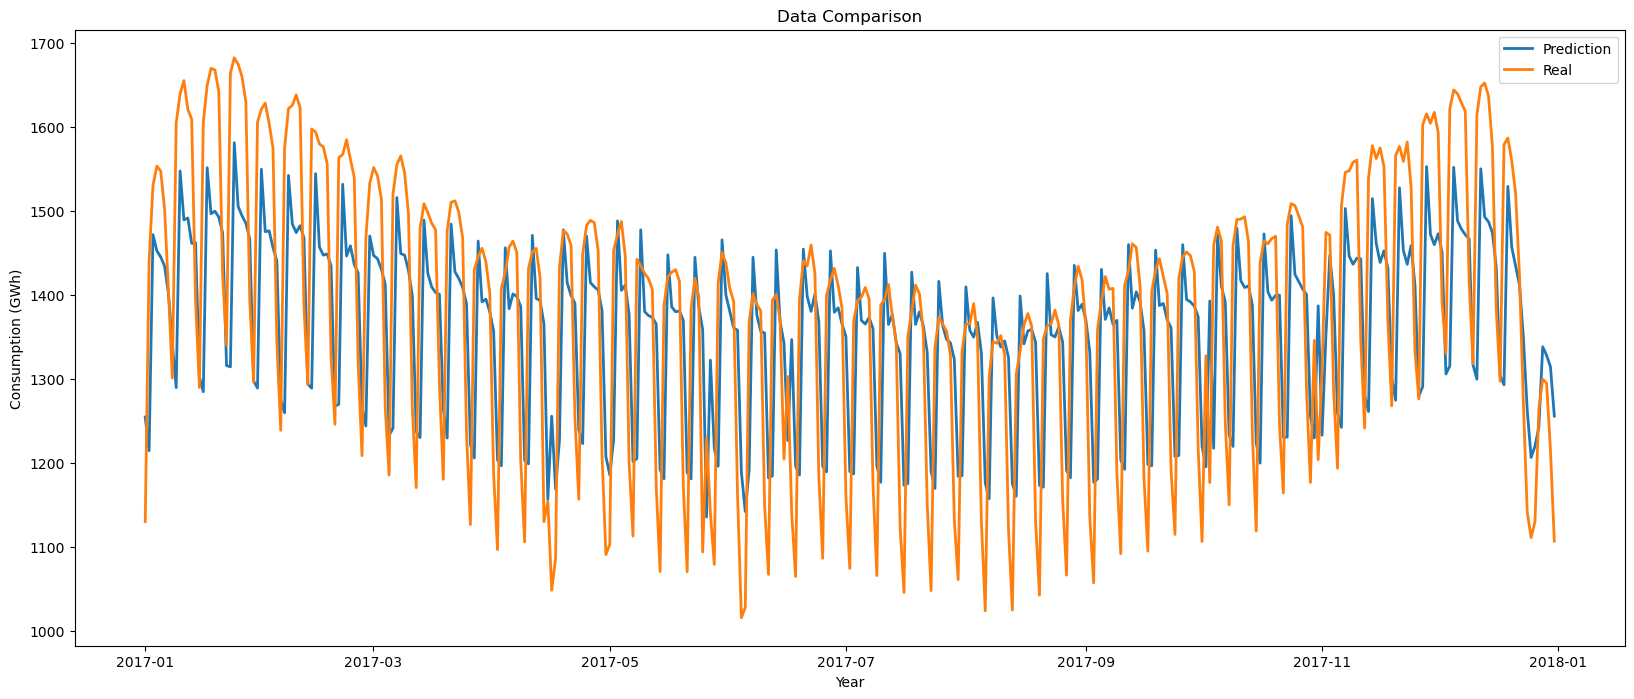

 
MLPRegressor(solver='lbfgs')
r2:  0.5928
MAE:  76.1858
MSE:  11027.964
RMSE:  105.0141


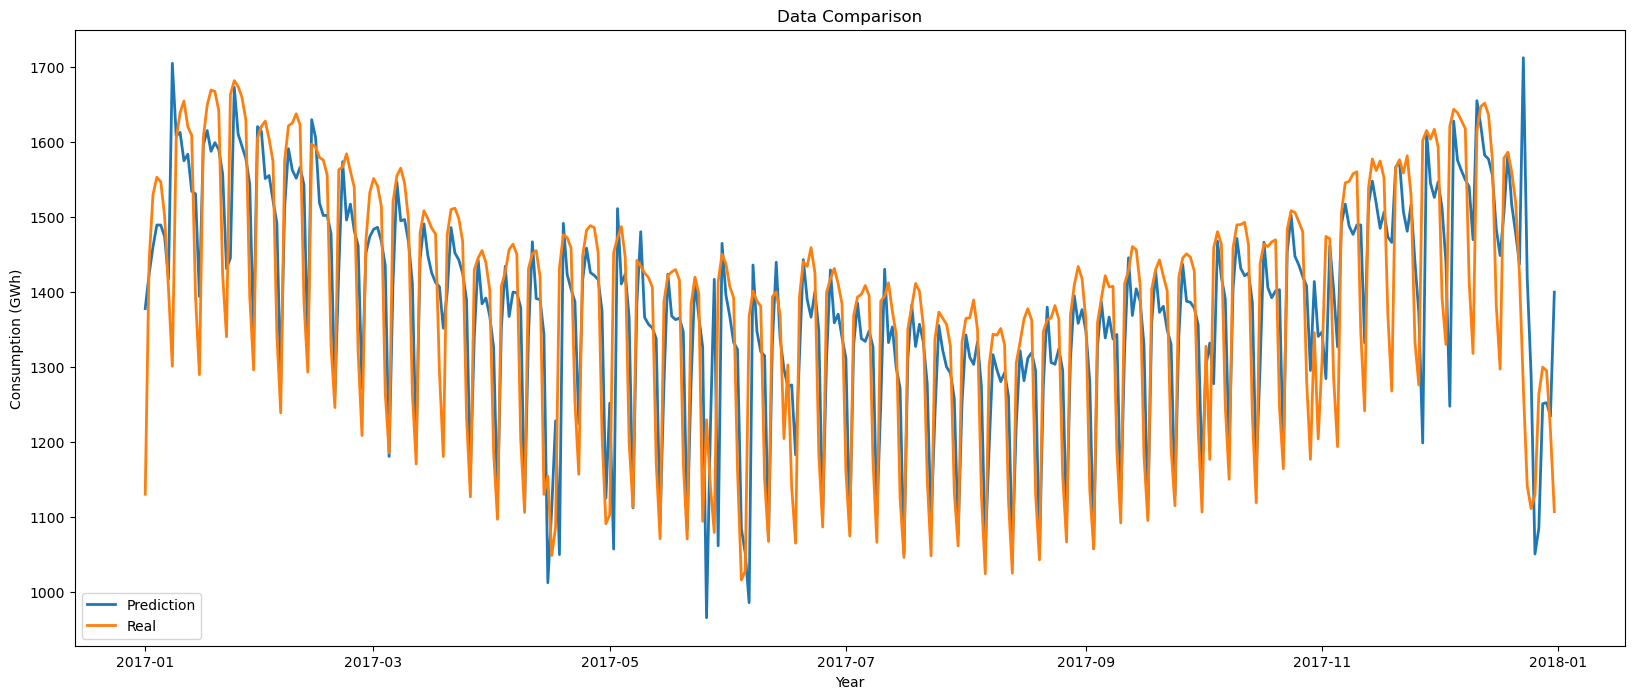

 
KNeighborsRegressor()
r2:  0.7109
MAE:  53.5502
MSE:  7830.2964
RMSE:  88.489


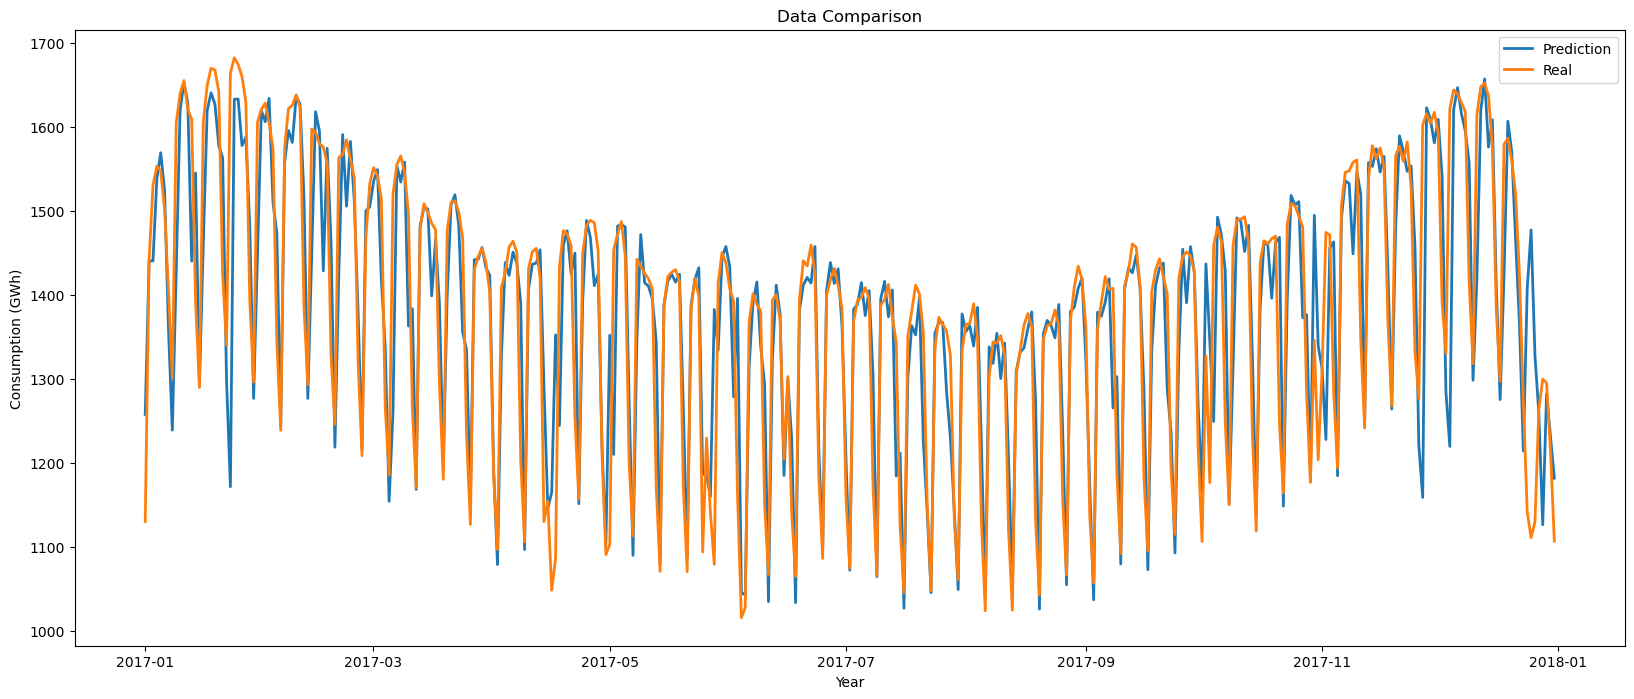

 
RandomForestRegressor(n_estimators=50)
r2:  0.6816
MAE:  56.2417
MSE:  8623.3306
RMSE:  92.8619


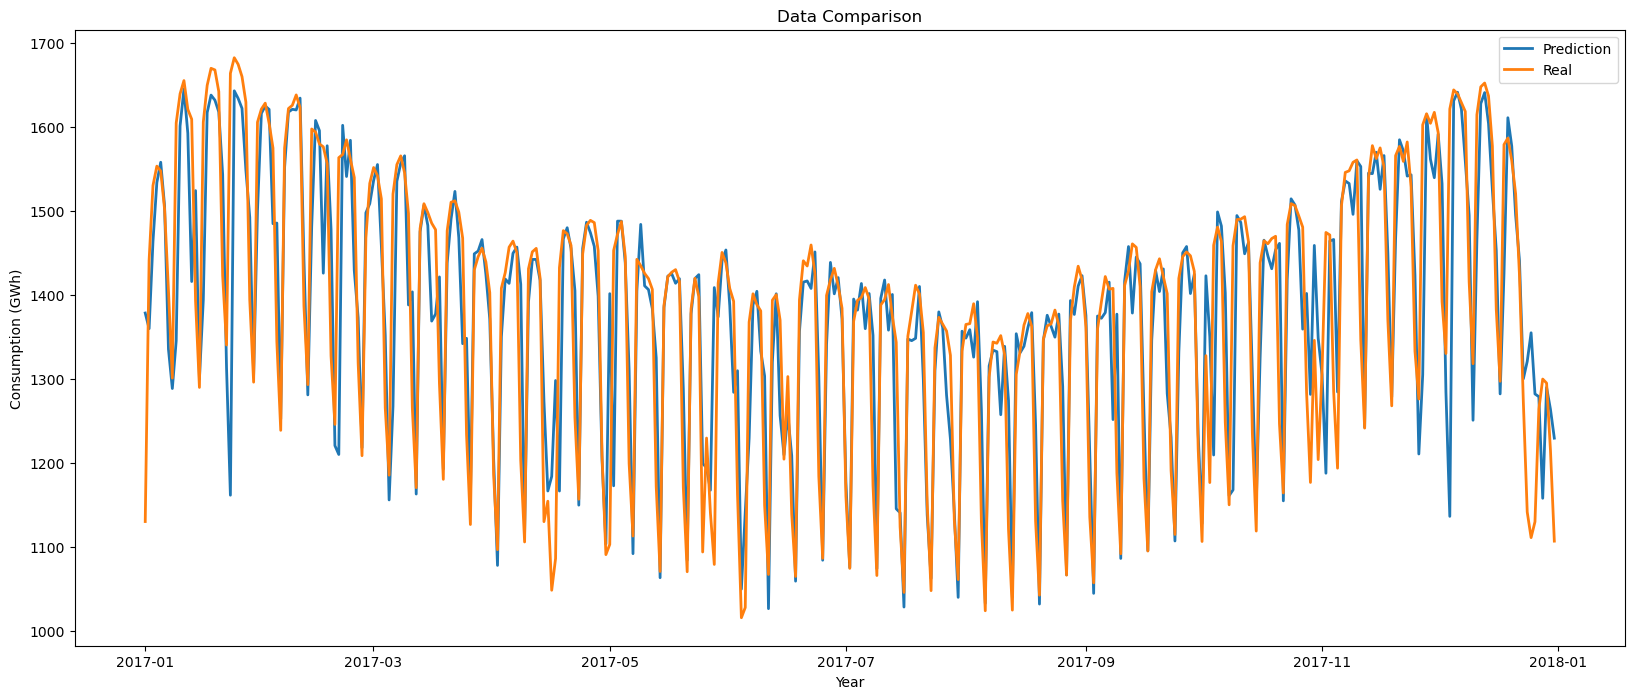

 
SVR(gamma='auto')
r2:  -0.0134
MAE:  136.5488
MSE:  27442.8101
RMSE:  165.6587


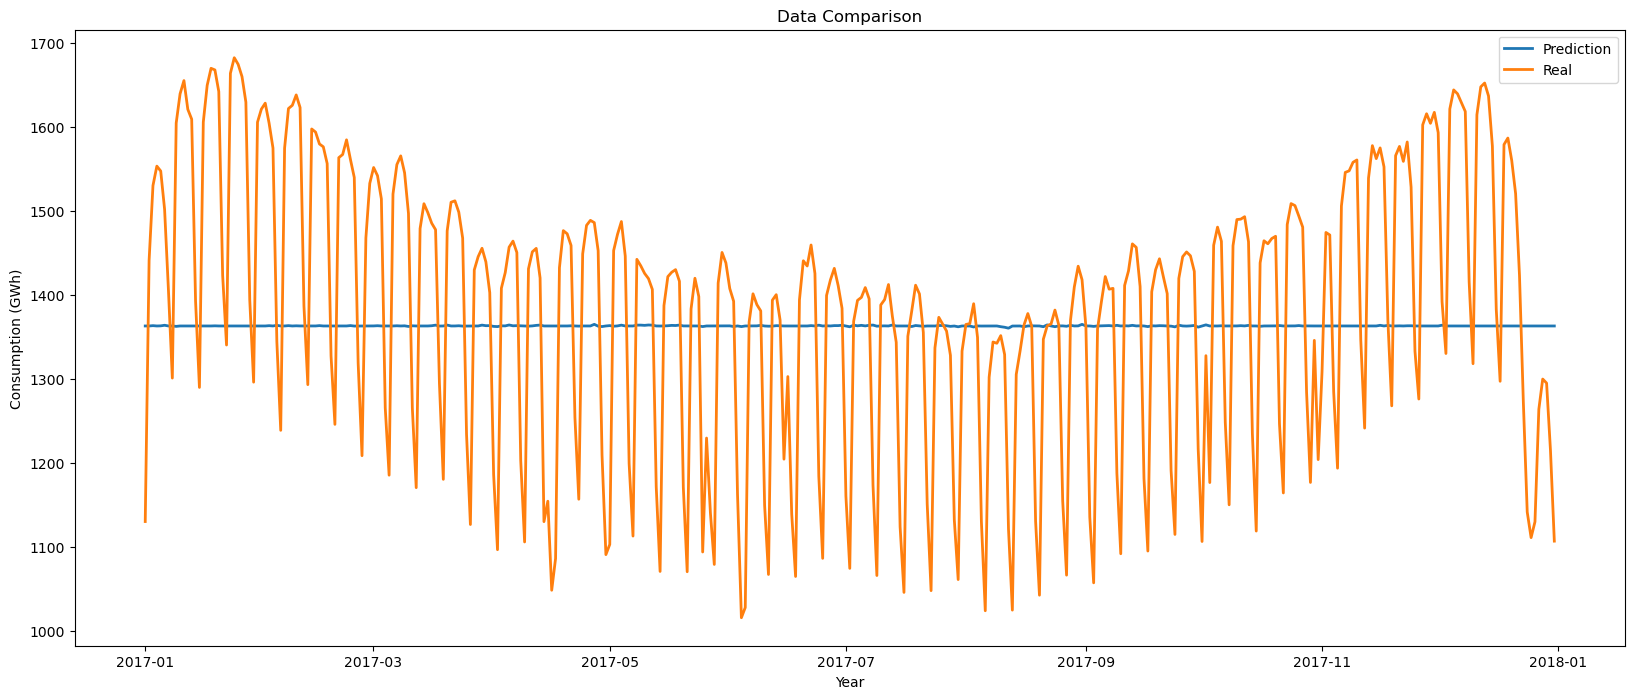

In [ ]:
# Цикл выполнения прогноза и сравнения реального временого хода
# со спрогнозированный результатом

for name, model in models:

    # Функция .fit() выполняет обучение модели (подгонку)
    # на основе тренировочного набора данных
    model = model.fit(X_train, y_train)

    # Функция .predict() выполняет прогнозирование
    # на основе тестового промежутка времени.
    y_pred = model.predict(X_test)

    # Далее выполняется передача результатов
    # прогнозирования y_pred и реального временного
    # хода y_test в функцию regression_results(), с целью
    # оценки точности итоговой модели.
    regression_results(y_test, y_pred, model)

    # Построение графика спрогнозированного и реальных временных ходов.
    fig, ax = plt.subplots(figsize = (20, 8))

    ax.plot(dataForPlot, y_pred, linewidth=2, label='Prediction')
    ax.plot(dataForPlot, y_test, linewidth=2, label='Real')
    ax.set_title('Data Comparison')
    ax.legend()
    ax.set_xlabel('Year')
    ax.set_ylabel('Consumption (GWh)')
    plt.show()

## Корректировки стационарности временного ряда, улучшение точности прогнозирования

Цель - повышение точности прогнозирования. Корректировка стационраности - такое
изменение временого хода исследуемого набора данных, при котором его среднее
значение не изменяется во времени (Параметры математического ожидания и дисперсии
постоянны).

In [ ]:
# Копирование исходного дф data в дф data_correction для дальнейшего изменения
data_correction = data[data_columns]

# Формирование новой колонки 'trend_residuals' дф data_correction в который заносится
# разность максимального значения годового тренда и каждого отсчета данного тренда
# с целью определения отклонения значений данного временного ряда (data_365d_rol['Consumption'])
# от его максималього значения. Полученные таким образом поправки будут ипользоваться в дальнейшем
# для выравнивания уровней амплитуды исследуемого временного хода (data['Consumption']).
data_correction['trend_residuals'] = data_365d_rol['Consumption'].max() - data_365d_rol['Consumption']

# Формирование скорректированного временного хода (data['Consumption']). В колонке 'Consumption_eq'
# (eq - equalized (выровненый)) заносится скорректированный ряд data_correction['Consumption'],
# коррекция которого выполнена путем прибавления вычесленных отклонения на основе линии тренда.
data_correction['Consumption_eq'] = data_correction['Consumption'] + data_correction['trend_residuals']

# Формирование тренда, в соответствие с которым выполнены поправки амплитуды
# временного хода (data['Consumption']) с целью графической визуализации поправок.
data_correction['trend_eq'] = data_365d_rol['Consumption'] + data_correction['trend_residuals'] * 2

# Фомирование тренда по выровненному временному ходу data_correction['Consumption_eq'].
data_correction['Consumption_eq_roll_7_day'] = data_correction['Consumption_eq'].rolling(window = 7, center = True).mean()

# Формирование дф с постоянным знаяением для гафичекой визуализации.
data_correction['constant'] = 1600

Text(0, 0.5, 'Consumption (GWh)')

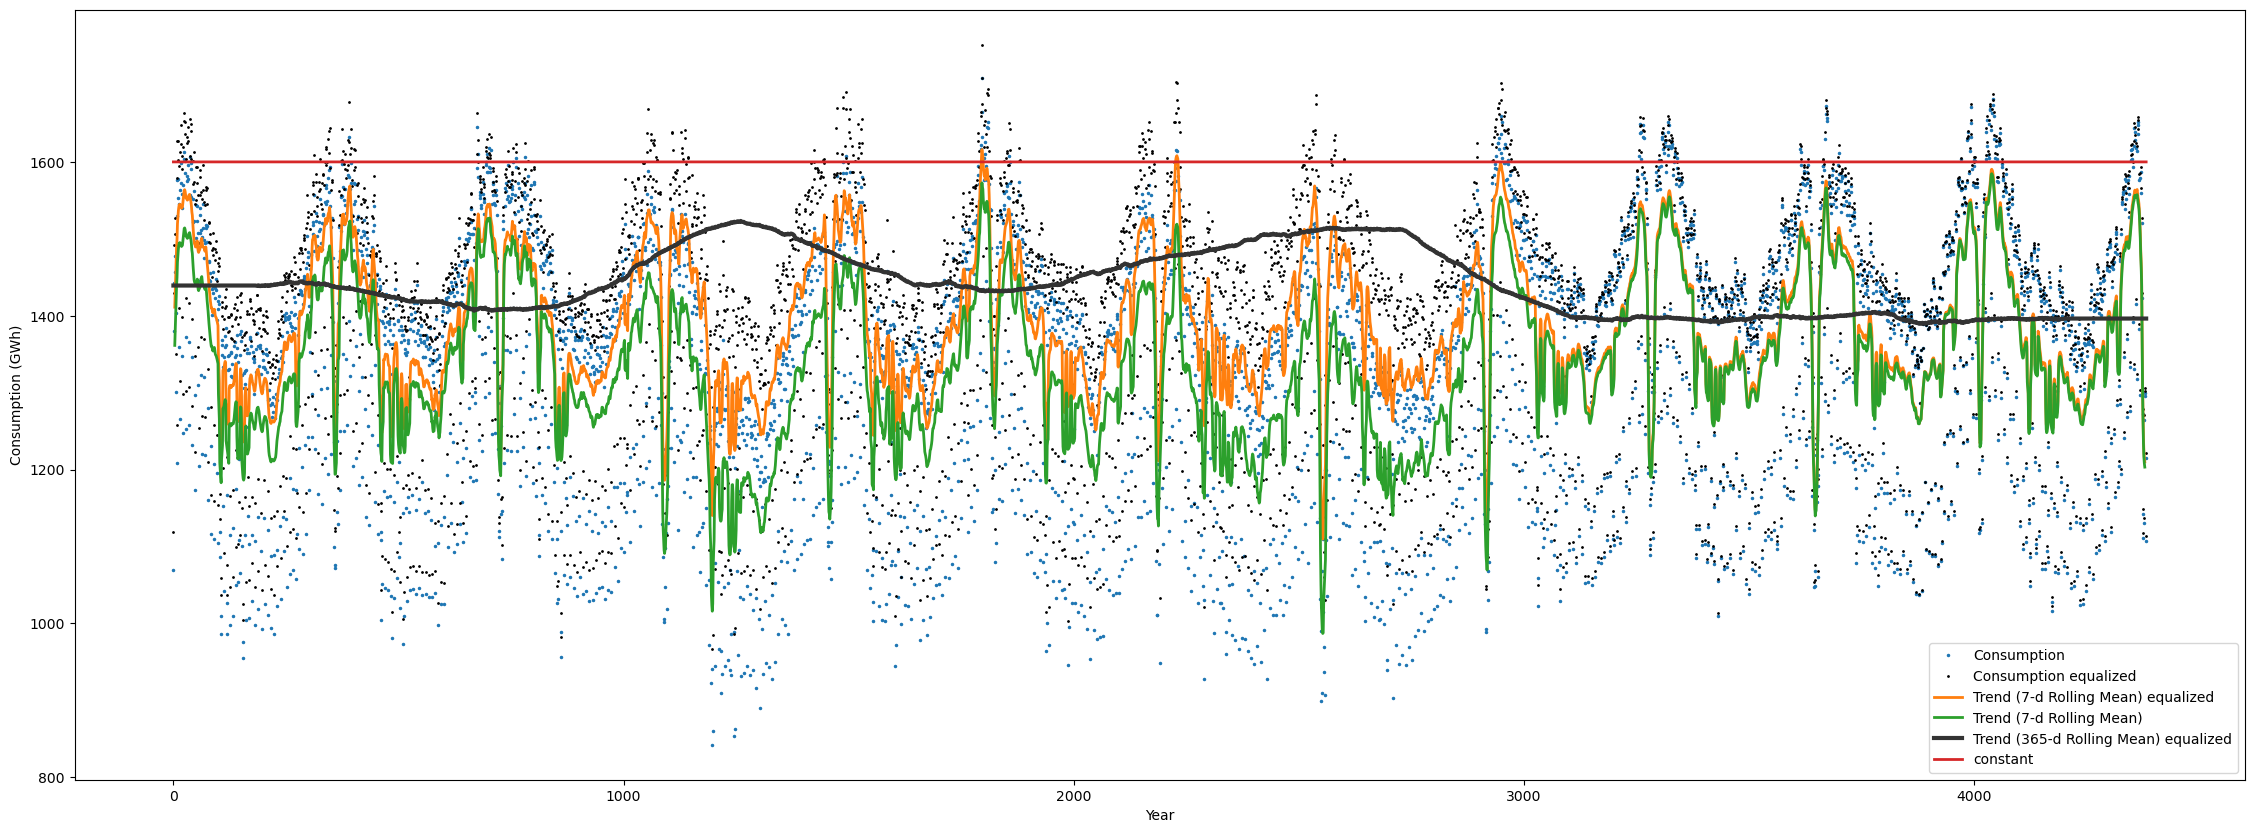

In [ ]:
# Построение графиков
fig, ax = plt.subplots(figsize = (28,10))

# Исходный временной ряд
ax.plot(data_correction['Consumption'], marker='.', markersize=3,linestyle='None', label='Consumption')

# Выровненный временной ряд
ax.plot(data_correction['Consumption_eq'], marker='.', markersize=2, color='0',linestyle='None', label='Consumption equalized')

# Выровненный тренд с усреднением по 7 дней
ax.plot(data_correction['Consumption_eq_roll_7_day'], linewidth=2, label='Trend (7-d Rolling Mean) equalized')

# Исходный тренд с усреднением по 7 дней
ax.plot(data_7d_rol['Consumption'], linewidth=2, label='Trend (7-d Rolling Mean)')

# Выровненный тренд с усреднением по 365 дней
ax.plot(data_correction['trend_eq'], color='0.2', linewidth=3, label='Trend (365-d Rolling Mean) equalized')

# ax.plot(data_correction['constant'], linewidth=2, label='7-d Rolling Mean')
ax.plot(data_correction['constant'], linewidth=2, label='constant')

# Добавление легенды на график
ax.legend()
# Название оси абсцисс
ax.set_xlabel('Year')
# Название оси ординат
ax.set_ylabel('Consumption (GWh)')

## Функция генерирования дополнительных временных признаком

Функция генерирования дополнительных признаком для временного ряда средствами функции .dt, которая позволяет выделять временные диапазоны с различным шагом (час, день, неделя, месяц, квартал, год и т.д.)

In [ ]:
data_correction

,Consumption,Wind,Solar,Wind+Solar,trend_residuals,Consumption_eq,trend_eq,Consumption_eq_roll_7_day,constant
0,1069.18400,NaN,NaN,NaN,49.691699,1118.875699,1439.297195,NaN,1600
1,1380.52100,NaN,NaN,NaN,49.691699,1430.212699,1439.297195,NaN,1600
2,1442.53300,NaN,NaN,NaN,49.691699,1492.224699,1439.297195,NaN,1600
3,1457.21700,NaN,NaN,NaN,49.691699,1506.908699,1439.297195,1411.163127,1600
4,1477.13100,NaN,NaN,NaN,49.691699,1526.822699,1439.297195,1430.991841,1600
...,...,...,...,...,...,...,...,...,...
4378,1263.94091,394.507,16.530,411.037,6.766128,1270.707038,1396.371624,1214.980256,1600
4379,1299.86398,506.424,14.162,520.586,6.766128,1306.630108,1396.371624,1210.031339,1600
4380,1295.08753,584.277,29.854,614.131,6.766128,1301.853658,1396.371624,NaN,1600
4381,1215.44897,721.247,7.467,728.714,6.766128,1222.215098,1396.371624,NaN,1600


In [ ]:
def Create_time_predictors(df):
    df['datetime'] = df.index # Копирование индексов дф в колонку
    df['hour'] = pd.to_datetime(data['Date']).dt.hour # Час
    df['dayofweek'] = pd.to_datetime(data['Date']).dt.dayofweek # День недели
    df['quarter'] = pd.to_datetime(data['Date']).dt.quarter # Квартал
    df['month'] = pd.to_datetime(data['Date']).dt.month # Месяц
    df['dayofyear'] = pd.to_datetime(data['Date']).dt.dayofyear # День года
    df['day'] = pd.to_datetime(data['Date']).dt.day # День
    df['weekofyear'] = pd.to_datetime(data['Date']).dt.isocalendar().week # Неделя
    df = df.drop('datetime', axis = 1) # Удаление из дф колонки
    # Операция возвращения функцией дф
    return df

In [ ]:
# import warnings
# warnings.filterwarnings('ignore')

In [ ]:
# from datetime import datetime

# Реализация прогнозирования на основе скорректированного датасета data_correction
# Формирмирование дополнительных временных признаков средствами функции Create_time_predictors()
data_correction = Create_time_predictors(data_correction)

# Удаление из дф неиспользуемых колонок
data_correction = data_correction.drop(['Consumption', 'Wind', 'Solar', 'Wind+Solar', 'trend_residuals', 'trend_eq', 'Consumption_eq_roll_7_day', 'constant'], axis = 1)
data_correction = data_correction.dropna().reset_index(drop=True)

In [ ]:
print(len(data), len(data_correction), sep='\n')

4383
4383


In [ ]:
X_train = data_correction[:4018].drop(['Consumption_eq'], axis = 1)
y_train = data_correction.loc[:4017, 'Consumption_eq']
X_test = data_correction[4018:].drop(['Consumption_eq'], axis = 1)
y_test = data_correction.loc[4018:, 'Consumption_eq']

TestDataForPlot = data['Date'][4018:]

In [ ]:
exp = [X_train, y_train, X_test, y_test, TrainDataForPlot, TestDataForPlot]
for el in exp:
    # print(el)
    print(el.shape)

(4018, 7)
(4018,)
(365, 7)
(365,)
(4018,)
(365,)


In [ ]:
# Объявление алгоритмов МО и аккумуляция их в массив
# для удобной работы в цикле
models = [] # Лист для хранения моделей
models.append(('LR', LinearRegression()))
models.append(('NN', MLPRegressor(solver = 'lbfgs'))) # solver - определение ядра принятия решений
models.append(('KNN', KNeighborsRegressor()))
models.append(('RF', RandomForestRegressor(n_estimators = 50))) # n_estimators - число деревьев в ансамбле
models.append(('SVR', SVR(gamma='auto', kernel='rbf'))) # kernel - ядро покоторому формируется опорный вектор

SVR: 0.016285 (0.026550)


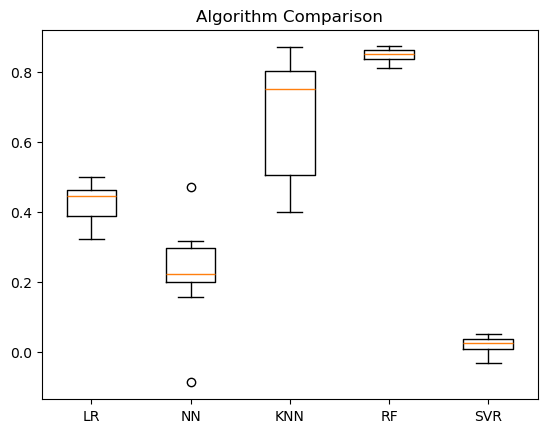

In [ ]:
# Рассчетный цикл
results = [] # Лист для хранения результата оценки модели
names = [] # Лист для хранения имени модели

for name, model in models:

    # TimeSeriesSplit определяет количество частей на которые будет разбит датасет,
    # переменная tscv используется как атрибут функции cross_val_score(), т.е.
    # определяет количество частей датасета по которым будет проведен перекрестный
    # анализ (валидация результатов по метрике R^2)
    tscv = TimeSeriesSplit(n_splits=10)
    cv_results = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')

    # Добавление результатов в лист results и names
    results.append(cv_results)
    names.append(name)

# Вывод результатов
print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

# График сравнения используемых алгоритмов
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()

 
LinearRegression()
r2:  0.4433
MAE:  98.5827
MSE:  15043.5814
RMSE:  122.6523


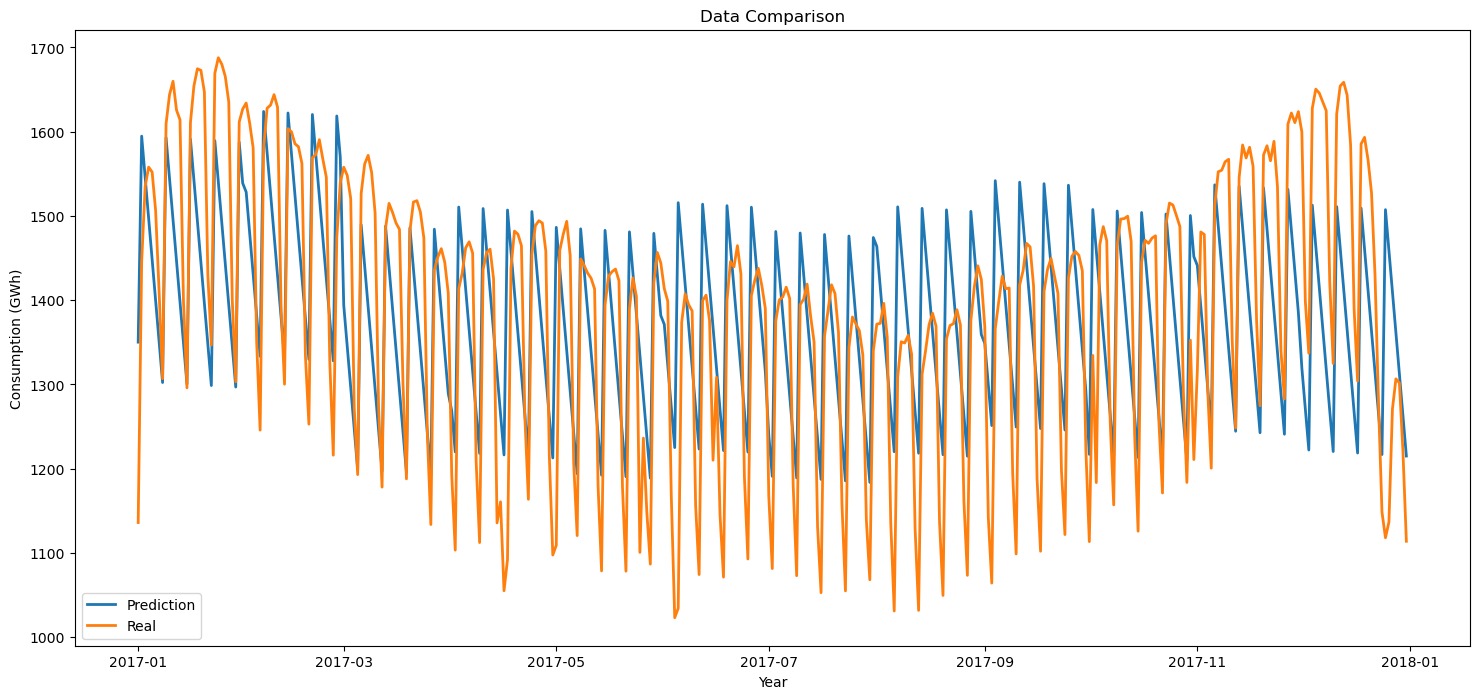

 
MLPRegressor(solver='lbfgs')
r2:  0.1985
MAE:  117.3356
MSE:  21657.7979
RMSE:  147.1659


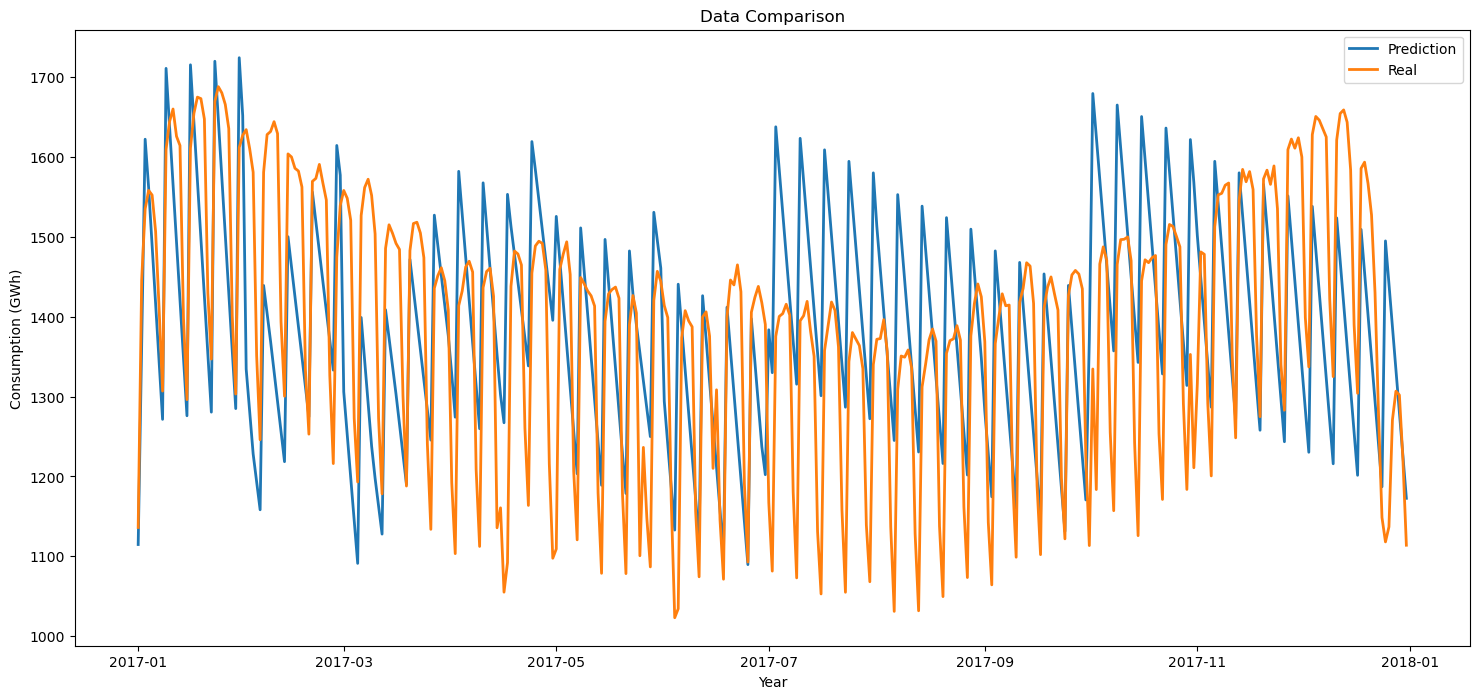

 
KNeighborsRegressor()
r2:  0.8785
MAE:  39.4804
MSE:  3282.1159
RMSE:  57.2898


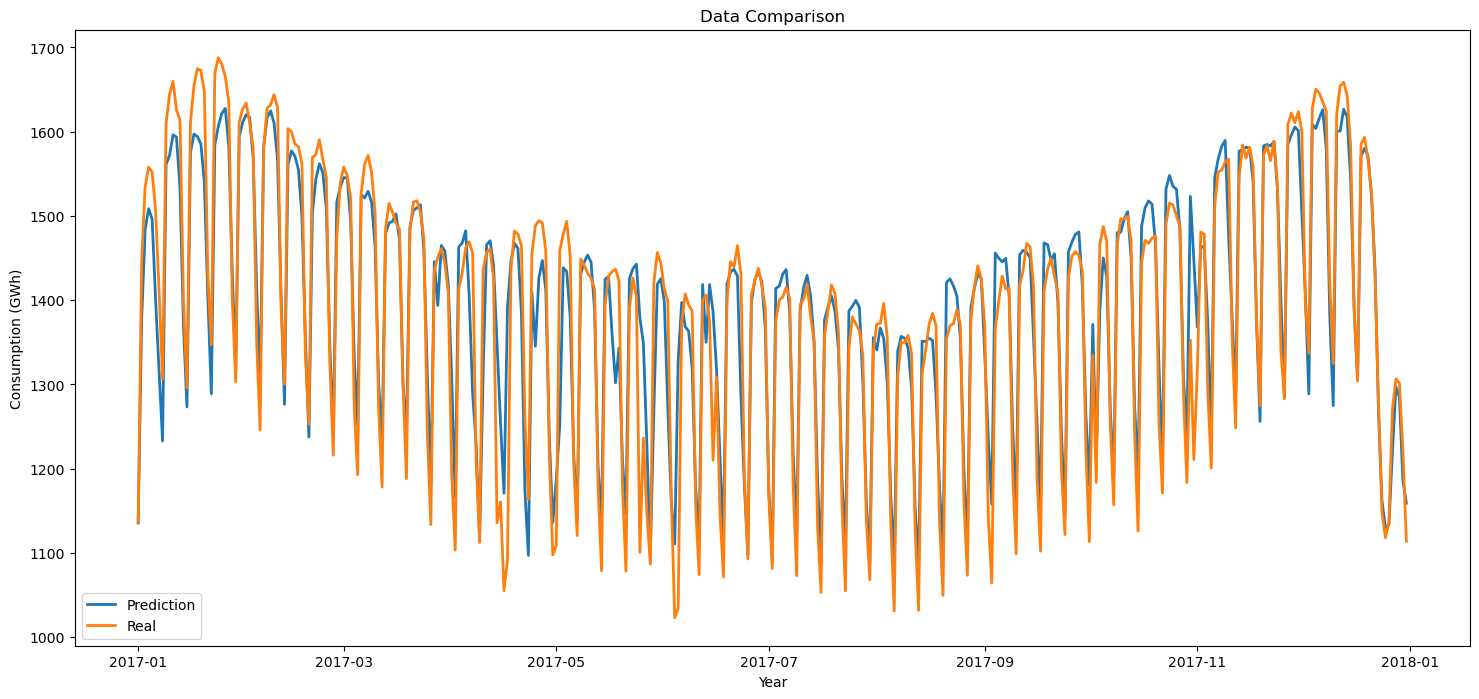

 
RandomForestRegressor(n_estimators=50)
r2:  0.936
MAE:  30.2996
MSE:  1729.664
RMSE:  41.5892


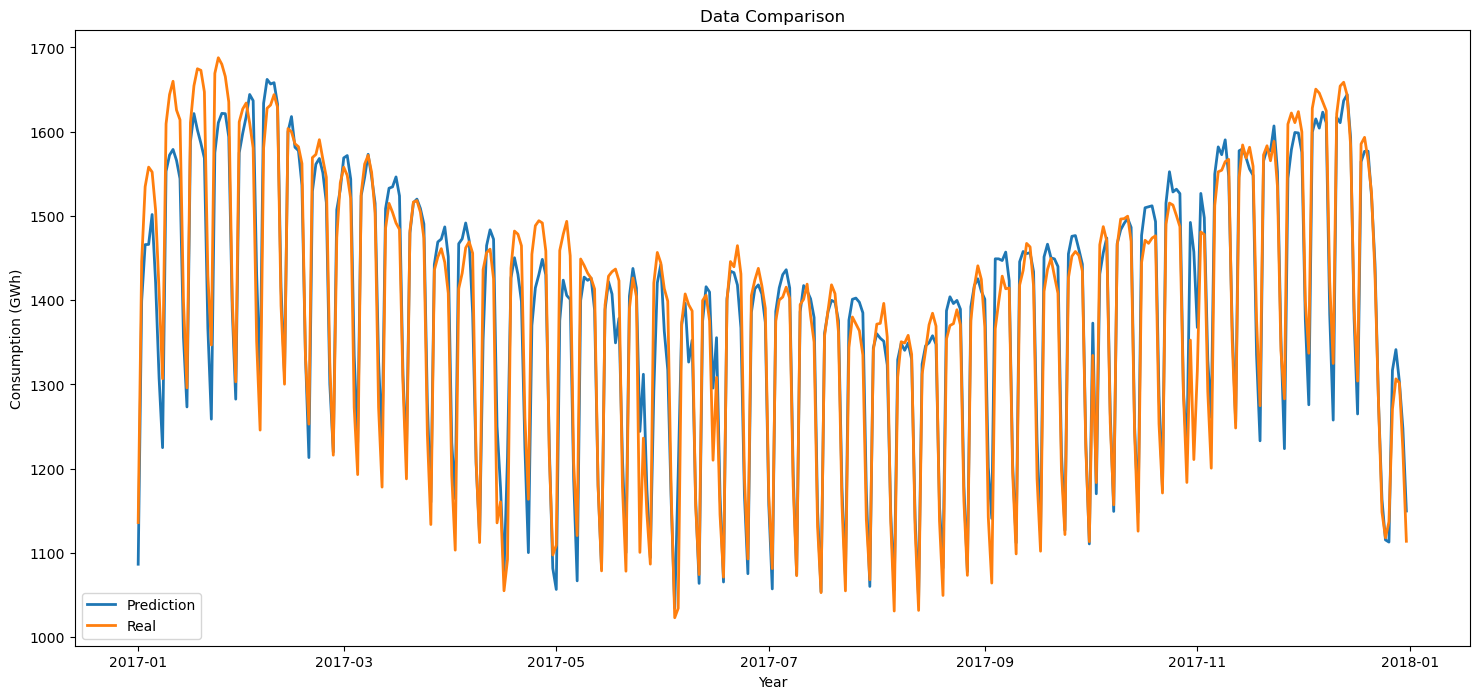

 
SVR(gamma='auto')
r2:  0.0553
MAE:  122.7271
MSE:  25527.5474
RMSE:  159.7734


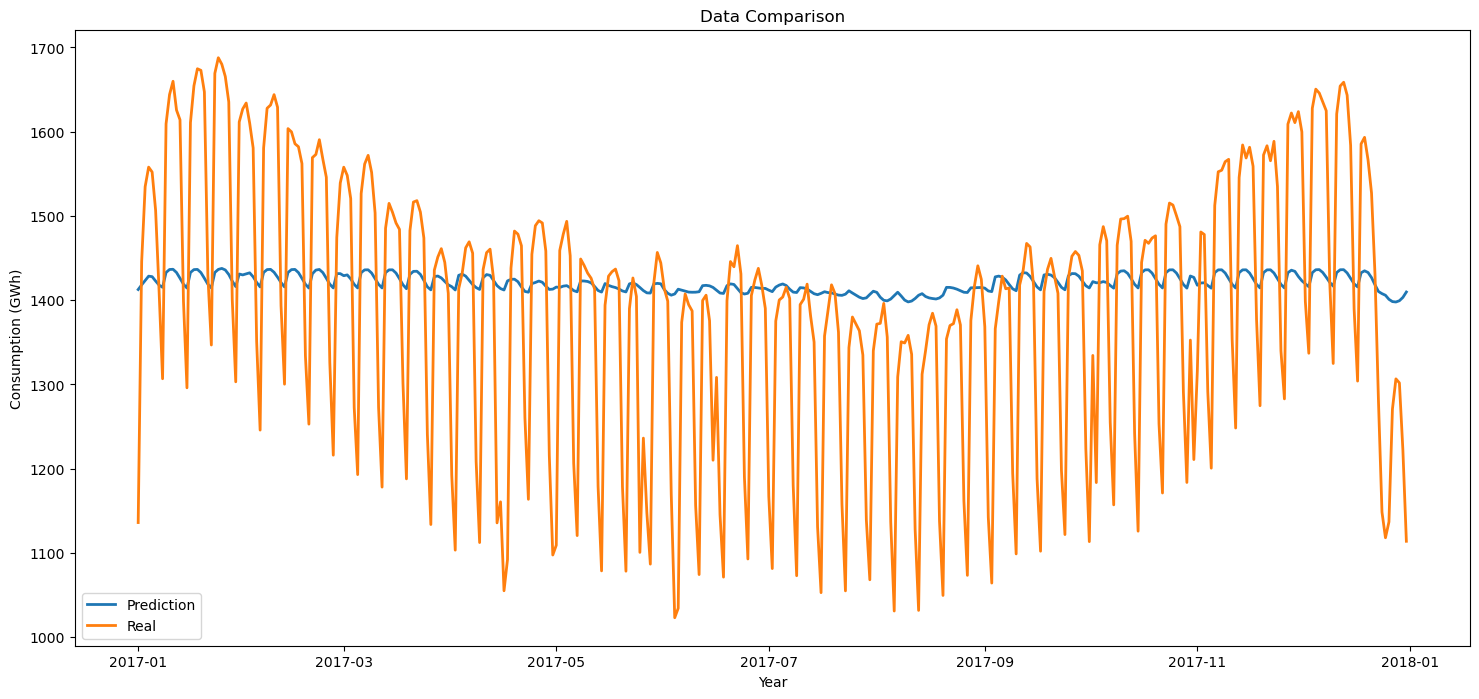

In [ ]:
# Цикл выполнения прогноза и сравнения реального временого хода
# со спрогнозированный результатом

for name, model in models:

    # Функция .fit() выполняет обучение модели (подгонку)
    # на основе тренировочного набора данных
    model = model.fit(X_train, y_train)

    # Функция .predict() выполняет прогнозирование
    # на основе тестового промежутка времени.
    y_pred = model.predict(X_test)

    # Далее выполняется передача результатов
    # прогнозирования y_pred и реального временного
    # хода y_test в функцию regression_results(), с целью
    # оценки точности итоговой модели.
    regression_results(y_test, y_pred, model)

    # Построение графика спрогнозированного и реальных временных ходов.
    fig, ax = plt.subplots(figsize = (18,8))
    ax.plot(TestDataForPlot, y_pred, linewidth=2, label='Prediction')
    ax.plot(TestDataForPlot, y_test, linewidth=2, label='Real')
    ax.set_title('Data Comparison')
    ax.legend()
    ax.set_xlabel('Year')
    ax.set_ylabel('Consumption (GWh)')
    plt.show()